In [1]:
from os import makedirs
import os

# print(os.environ)
from typing import Dict, List, Tuple

import torch
from torch.utils.data import DataLoader
from torch.nn.utils import parameters_to_vector

import argparse
from archs import load_architecture
from utilities import get_loss_and_acc, compute_losses, \
    save_files, save_files_final, get_hessian_eigenvalues, make_base_directory, iterate_dataset
from data import load_dataset, DATASETS, take_first
import NGD
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio
from tempfile import TemporaryDirectory
from matplotlib.widgets import Slider
import pickle


# num_cores = os.cpu_count()
# torch.set_num_threads(num_cores)
# torch.set_num_interop_threads(max(1, num_cores // 2))  # usually optimal to set lower

# print(f"Using {num_cores} cores for training.")

directory = "/home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/fc-tanh/seed_24/ce/gd/lr_0.01/snapshots"

arch_id = "fc-tanh"
dataset_id = "cifar10-5k"
loss = "ce"

train_dataset, test_dataset = load_dataset(dataset_id, loss)

def run_fn(snapshot_directory, max_timestamp=None):
    def run_on_shapshots(fun):
        results = {}
        snapshot_model = load_architecture(arch_id, dataset_id)
        
        filenames = os.listdir(snapshot_directory)
        if max_timestamp is not None:
            filenames = [f for f in os.listdir(snapshot_directory) if int(f) <= max_timestamp]
        
        for filename in tqdm.tqdm(filenames, desc="Loading snapshots", total=len(filenames)):
            timestamp = int(filename)
            if (max_timestamp is not None) and (timestamp > max_timestamp):
                continue
            
            snapshot_model.load_state_dict(
                torch.load(os.path.join(snapshot_directory, filename), map_location="cpu")
            )
            snapshot_model.eval()
            snapshot_model.to("cpu")
            results[filename] = fun(snapshot_model)
        return results
    return run_on_shapshots

class datapoint:
    def __init__(self, emp_FIM_diag_norm, FIM_diag_norm, loglikelihood, mse, class_id, correct):
        self.loglikelihood = loglikelihood.item()
        self.mse = mse.item()
        self.class_id = class_id
        self.emp_FIM_diag_norm = emp_FIM_diag_norm.item()
        self.FIM_diag_norm = FIM_diag_norm.item()
        self.correct = correct.item()

def calc_datapoint(X, y, model, activation_fn, epsilon, device="cuda", num_classes=10):
    X = X.to(device)
    y = y.to(device)
    
    class_id = torch.argmax(y, dim=1).item() if y.ndim > 1 else y.item()

    if y.ndim == 1:
        y = torch.nn.functional.one_hot(y, num_classes=num_classes).float().to(device)

    model.zero_grad()
    model_logits = model(X)
    model_probs = activation_fn(model_logits) if activation_fn else model_logits

    llh = torch.sum(model_probs * y, dim=1)
    true_label_llh = torch.log(llh + epsilon)
    mse = torch.mean((model_logits - y) ** 2)
    
    grads = torch.autograd.grad(true_label_llh, model.parameters(), retain_graph=False)
    emp_FIM_diag_norm = torch.sqrt(sum(torch.sum(g.detach()**2) for g in grads))

    FIM_diag_norm_sum = 0.0
    for cl in range(num_classes):
        model.zero_grad()
        model_logits = model(X)
        model_probs = activation_fn(model_logits) if activation_fn else model_logits
        likeh = model_probs[0][cl]

        model.zero_grad()
        cl_loglikeh = torch.log(likeh + epsilon)
        grads = torch.autograd.grad(cl_loglikeh, model.parameters(), retain_graph=False, allow_unused=True)
        FIM_diag_norm_sum += likeh * sum(torch.sum((g.detach() ** 2)) for g in grads if g is not None)

    FIM_diag_norm = torch.sqrt(FIM_diag_norm_sum)

    correct = (torch.argmax(model_probs, dim=1) == class_id).detach().cpu()

    return datapoint(
        emp_FIM_diag_norm.detach().cpu(),
        FIM_diag_norm.detach().cpu(),
        true_label_llh.detach().cpu(),
        mse.detach().cpu(),
        class_id,
        correct
    )

def calc_fisher_diag_dict(
    dataset,
    model: torch.nn.Module,
    epsilon: float = 1e-8,
    device: str = "cpu", 
    activation_fn=torch.nn.Softmax(dim=1),
    limit: int = None,
):
    result = []
    limit = limit if limit is not None else len(dataset)

    for i, (X, y) in enumerate(iterate_dataset(dataset, 1)):
        if i >= limit:
            break
        with torch.no_grad():
            _ = model(X.to(device))  # dry run to prepare model
        result.append(calc_datapoint(X, y, model, activation_fn, epsilon, device))

    return result

def calc_datapoints_test(model):
    return calc_fisher_diag_dict(
        test_dataset,
        model,
        limit = 1000,
        device="cpu"
    )

def calc_datapoints_train(model):
    return calc_fisher_diag_dict(
        train_dataset,
        model,
        limit = 1000,
        device="cpu"
    )
    
def calc_train_acc(model):
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=4)
    


def save_fim_video(timestamp_to_datapoints, output_path="fim_plot_video.mp4", fps=2):
    timestamps = sorted(list(timestamp_to_datapoints.keys()), key=lambda x: int(x))

    with TemporaryDirectory() as tempdir:
        frame_paths = []

        for idx, timestamp in enumerate(timestamps):
            datapoints = timestamp_to_datapoints[timestamp]
            fim_diag_log = torch.tensor([np.log10(dp.FIM_diag_norm) for dp in datapoints])
            emp_fim_log = torch.tensor([np.log10(dp.emp_FIM_diag_norm) for dp in datapoints])
            correct_mask = torch.tensor([dp.correct for dp in datapoints], dtype=torch.bool)
            incorrect_mask = ~correct_mask
            min_val = -1
            max_val = 2

            # Plot frame
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='x = y')
            ax.scatter(fim_diag_log[correct_mask], emp_fim_log[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
            ax.scatter(fim_diag_log[incorrect_mask], emp_fim_log[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
            ax.set_xlabel('log(||DIAG(FIM)||)')
            ax.set_ylabel('log(||DIAG(EFIM)||')
            ax.set_title(f'Timestamp: {timestamp}')
            ax.legend()
            ax.grid(True)

            frame_path = os.path.join(tempdir, f"frame_{idx:04d}.png")
            plt.savefig(frame_path)
            frame_paths.append(frame_path)
            plt.close(fig)

        # Write video from saved frames
        with imageio.get_writer(output_path, fps=fps) as writer:
            for frame_path in frame_paths:
                writer.append_data(imageio.imread(frame_path))

    print(f"Video saved to {output_path}")

class RandomLabelDataset:
    def __init__(self, original_dataset, num_classes=10):
        self.original_dataset = original_dataset
        self.num_classes = num_classes

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        X, y = self.original_dataset[idx]
        if y.ndim <= 1:
            y = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()
        return X, torch.randint(0, self.num_classes, size=(y.shape[0],)).float()
    
    def __iter__(self):
        for X, y in self.original_dataset:
            if y.ndim <= 1:
                y_ret = torch.randint(0, self.num_classes, [1]).float()
            else:
                y_ret = torch.randint(0, self.num_classes, size=(y.shape[0],)).float() 
            yield X, y_ret

class RandomDataset:
    def __init__(self, original_dataset, num_classes=10):
        self.original_dataset = original_dataset
        self.num_classes = num_classes
        
    def __len__(self):
        return len(self.original_dataset)
    
    def __getitem__(self, idx):
        X, y = self.original_dataset[idx]
        if y.ndim <= 1:
            y = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()
        return torch.randn_like(X), torch.randint(0, self.num_classes, size=(y.shape[0],)).float()
    
    def __iter__(self):
        for X, y in self.original_dataset:
            if y.ndim <= 1:
                y = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()
            yield torch.randn_like(X), torch.randint(0, self.num_classes, size=(y.shape[0],)).float()
            
    
def calc_datapoints_random(model, dataset):
    return calc_fisher_diag_dict(
        RandomLabelDataset(dataset),
        model,
        limit = 1000,
        device="cpu"
    )




def plot_fim_analysis(datapoints):
    fig, axs = plt.subplots(3, 2, figsize=(14, 16))
    axs = axs.flatten()

    # Helper: extract tensors
    emp_fim_log = torch.tensor([np.log(dp.emp_FIM_diag_norm) for dp in datapoints])
    emp_fim = torch.tensor([dp.emp_FIM_diag_norm for dp in datapoints])
    fim = torch.tensor([dp.FIM_diag_norm for dp in datapoints])
    fim_log = torch.tensor([np.log(dp.FIM_diag_norm) for dp in datapoints])
    fim_log10 = torch.tensor([np.log10(dp.FIM_diag_norm) for dp in datapoints])
    emp_fim_log10 = torch.tensor([np.log10(dp.emp_FIM_diag_norm) for dp in datapoints])
    losses = torch.tensor([dp.loglikelihood for dp in datapoints])
    losses_exp = torch.exp(losses)
    correct_flags = torch.tensor([dp.correct for dp in datapoints], dtype=torch.bool)

    correct_mask = correct_flags
    incorrect_mask = ~correct_mask

    # Plot 1: Histogram with emp_FIM_diag_norm
    bins = np.histogram_bin_edges(emp_fim_log10, bins='auto')
    correct_hist, _ = np.histogram(emp_fim_log10[correct_mask], bins=bins)
    incorrect_hist, _ = np.histogram(emp_fim_log10[incorrect_mask], bins=bins)
    bar_widths = np.diff(bins)
    x_pos = bins[:-1]
    axs[0].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
    axs[0].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
    axs[0].set_xlabel('log10(||DIAG(EFIM)||)')
    axs[0].set_ylabel('Count')
    axs[0].set_title('Histogram: norm of EFIM diagonal with correctness')
    axs[0].legend()

    # Plot 2: Histogram with FIM_diag_norm
    bins = np.histogram_bin_edges(fim_log10, bins='auto')
    correct_hist, _ = np.histogram(fim_log10[correct_mask], bins=bins)
    incorrect_hist, _ = np.histogram(fim_log10[incorrect_mask], bins=bins)
    bar_widths = np.diff(bins)
    x_pos = bins[:-1]
    axs[1].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
    axs[1].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
    axs[1].set_xlabel('log10(||DIAG(FIM)||)')
    axs[1].set_ylabel('Count')
    axs[1].set_title('Histogram: norm of EFIM diagonal with correctness')
    axs[1].legend()

    # Plot 3: FIM_diag_norm vs Loss
    axs[2].scatter(fim_log[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
    axs[2].scatter(fim_log[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
    axs[2].set_xlabel('log(||DIAG(FIM)||)')
    axs[2].set_ylabel('Loss')
    axs[2].set_title('FIM diag norm vs Loss')
    axs[2].legend()
    axs[2].grid(True)

    # Plot 4: emp_FIM_diag_norm vs Loss
    axs[3].scatter(emp_fim_log[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
    axs[3].scatter(emp_fim_log[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
    axs[3].set_xlabel('log(||DIAG(EFIM)||)')
    axs[3].set_ylabel('Loss (CE)')
    axs[3].set_title('EFIM diag norm vs Loss')
    axs[3].legend()
    axs[3].grid(True)

    # Plot 5: FIM_diag_norm vs emp_FIM_diag_norm
    min_val = min(fim_log10.min(), emp_fim_log10.min()).item()
    max_val = max(fim_log10.max(), emp_fim_log10.max()).item()
    axs[4].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='x = y')
    axs[4].scatter(fim_log10[correct_mask], emp_fim_log10[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
    axs[4].scatter(fim_log10[incorrect_mask], emp_fim_log10[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
    axs[4].set_xlabel('log(||DIAG(FIM)||)')
    axs[4].set_ylabel('log(||DIAG(EFIM)||)')
    axs[4].set_title('FIM vs emp FIM norm')
    axs[4].legend()
    axs[4].grid(True)

    # Plot 6: Difference in norms vs Loss
    diffs = emp_fim_log
    axs[5].scatter(diffs[correct_mask], losses_exp[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
    axs[5].scatter(diffs[incorrect_mask], losses_exp[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
    axs[5].axvline(0, linestyle='--', color='gray', linewidth=1)
    axs[5].set_xlabel('log(||DIAG(EFIM)||) - log(||DIAG(FIM)||)')
    axs[5].set_ylabel('Loss')
    axs[5].set_title('Difference in FIM Norms vs Loss')
    axs[5].legend()
    axs[5].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
results_test = run_fn(directory)(calc_datapoints_test)
results_train= run_fn(directory)(calc_datapoints_train)

In [2]:
flow_directory = "/home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/fc-tanh/seed_23/ce/flow/tick_1.0/snapshots"

results_flow_test = run_fn(flow_directory)(calc_datapoints_test)
results_flow_train = run_fn(flow_directory)(calc_datapoints_train)

Loading snapshots:   0%|          | 0/200 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
save_fim_video(results_test, output_path="fim_plot_video_test.mp4", fps=5)
save_fim_video(results_train, output_path="fim_plot_video_train.mp4", fps=5)
save_fim_video(results_flow_test, output_path="fim_plot_video_flow_test.mp4", fps=5)
save_fim_video(results_flow_train, output_path="fim_plot_video_flow_train.mp4", fps=5)

In [3]:
# save the results to a file with pickle
def save_results_to_file(results, filename):
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
save_results_to_file(results_test, "results_test.pkl")
save_results_to_file(results_train, "results_train.pkl")
save_results_to_file(results_flow_test, "results_flow_test.pkl")
save_results_to_file(results_flow_train, "results_flow_train.pkl")

NameError: name 'results_test' is not defined

In [4]:
# load the results from a file with pickle
def load_results_from_file(filename):
    with open(filename, 'rb') as f:
        print(f"Loading results from {filename}")
        return pickle.load(f)
results_test = load_results_from_file("results_test.pkl")
results_train = load_results_from_file("results_train.pkl")
results_flow_test = load_results_from_file("results_flow_test.pkl")
results_flow_train = load_results_from_file("results_flow_train.pkl")

Loading results from results_test.pkl
Loading results from results_train.pkl
Loading results from results_flow_test.pkl
Loading results from results_flow_train.pkl


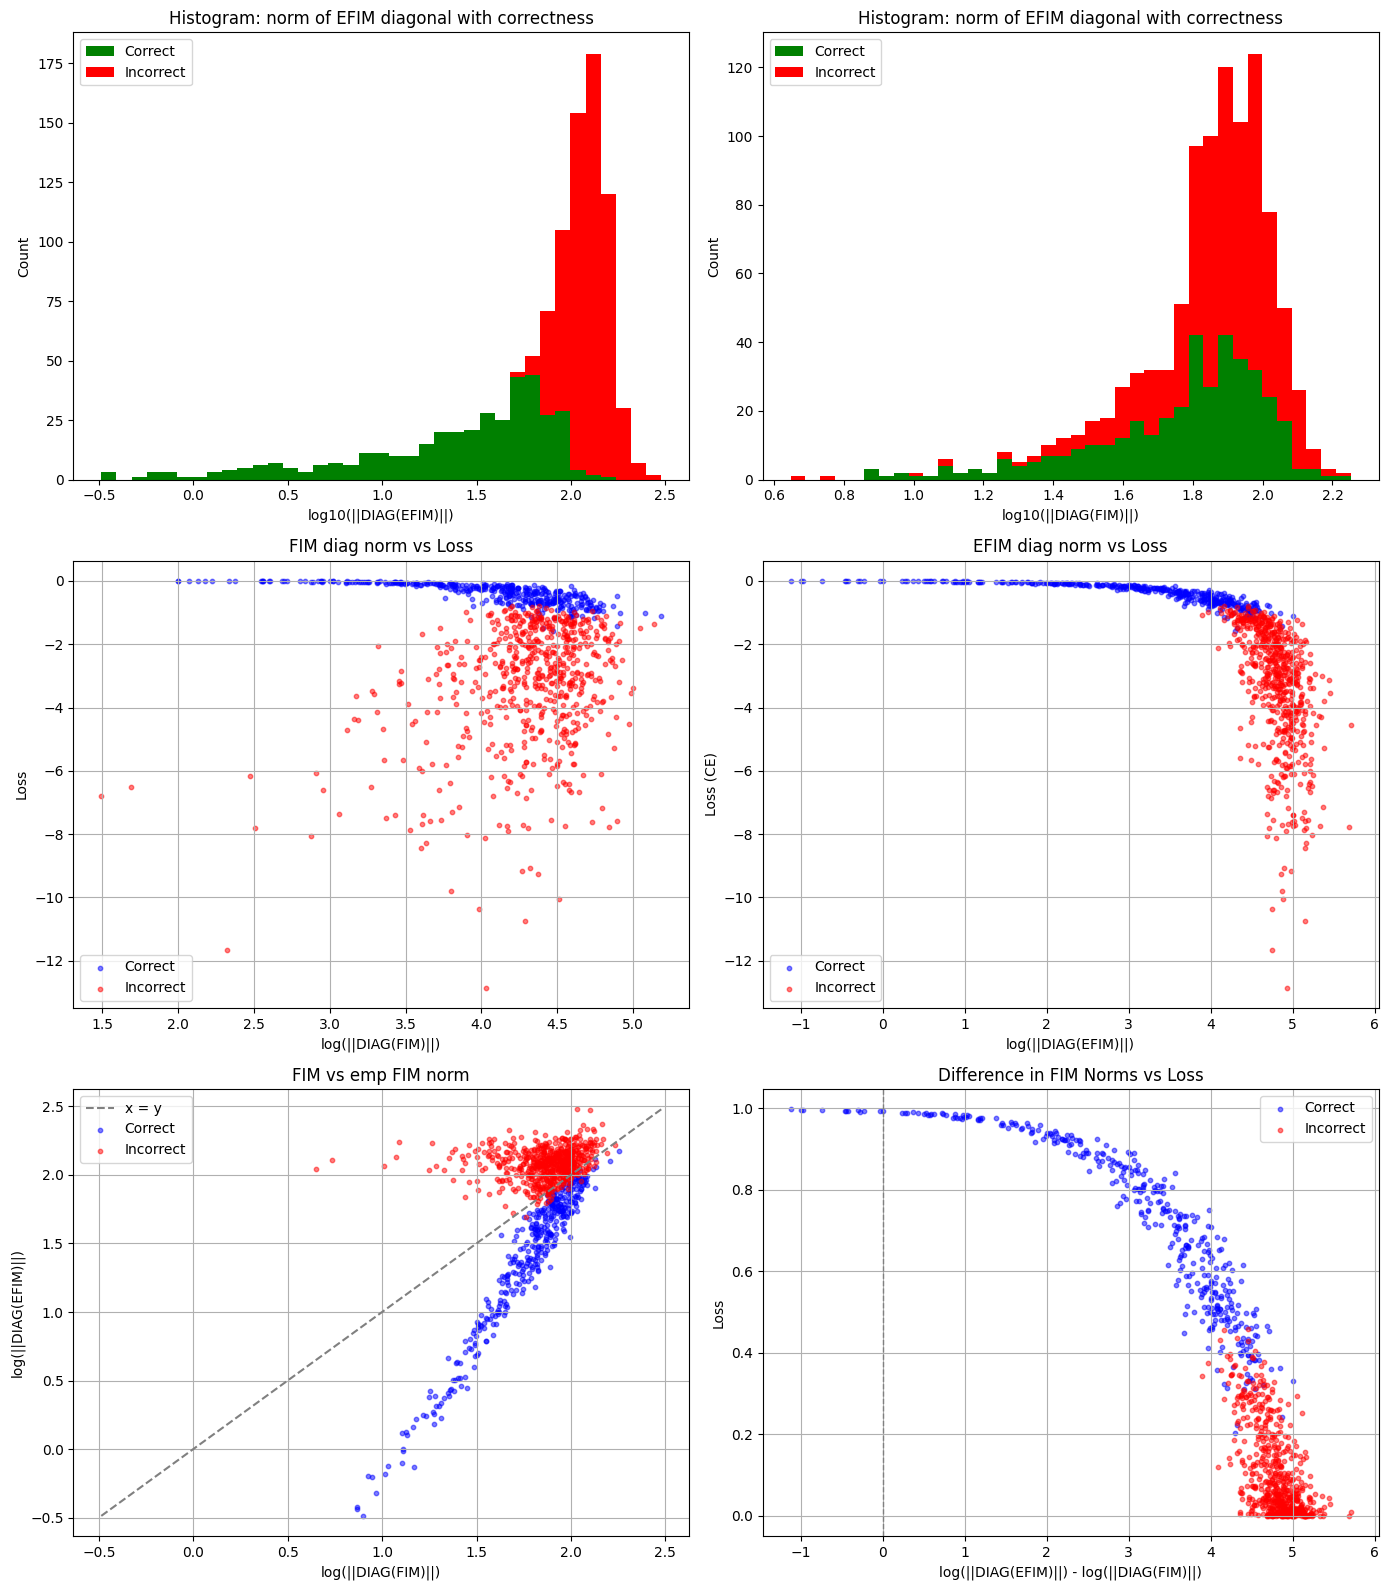

In [5]:
plot_fim_analysis(results_test['5000'])

In [ ]:
results_random_label_test = run_fn(directory, max_timestamp=5000)(lambda model: calc_fisher_diag_dict(
    RandomLabelDataset(test_dataset),
    model,
    limit = 100,
    device="cpu"
))


In [ ]:
save_fim_video(results_random_label_test, output_path="fim_plot_video_random_test.mp4", fps=5)

In [ ]:
results_total_random_test = run_fn(directory, max_timestamp=5000)(lambda model: calc_fisher_diag_dict(
    RandomDataset(test_dataset),
    model,
    limit = 100,
    device="cpu"
))
save_fim_video(results_total_random_test, output_path="fim_plot_video_total_random_test.mp4", fps=5)

In [ ]:
results_random_label_train = run_fn(directory, max_timestamp=5000)(lambda model: calc_fisher_diag_dict(
    RandomLabelDataset(train_dataset),
    model,
    limit = 100,
    device="cpu"
))
save_fim_video(results_random_label_train, output_path="fim_plot_video_random_label_train.mp4", fps=5)

results_total_random_train = run_fn(directory, max_timestamp=5000)(lambda model: calc_fisher_diag_dict(
    RandomDataset(train_dataset),
    model,
    limit = 100,
    device="cpu"
))
save_fim_video(results_total_random_train, output_path="fim_plot_video_total_random_train.mp4", fps=5)